# Class imbalance, transactions, and temporal drift

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd()
if not (ROOT / "config.json").exists():
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"
assert (REPORTS / "run_manifest.json").exists(), "Run python -m fraudgraph.pipeline --download first"
manifest = json.loads((REPORTS / "run_manifest.json").read_text())
print("Evidence run:", manifest["run_id"])
def figure(name):
    display(Image(filename=str(REPORTS / "figures" / name)))


Evidence run: 20260923T163139886696Z


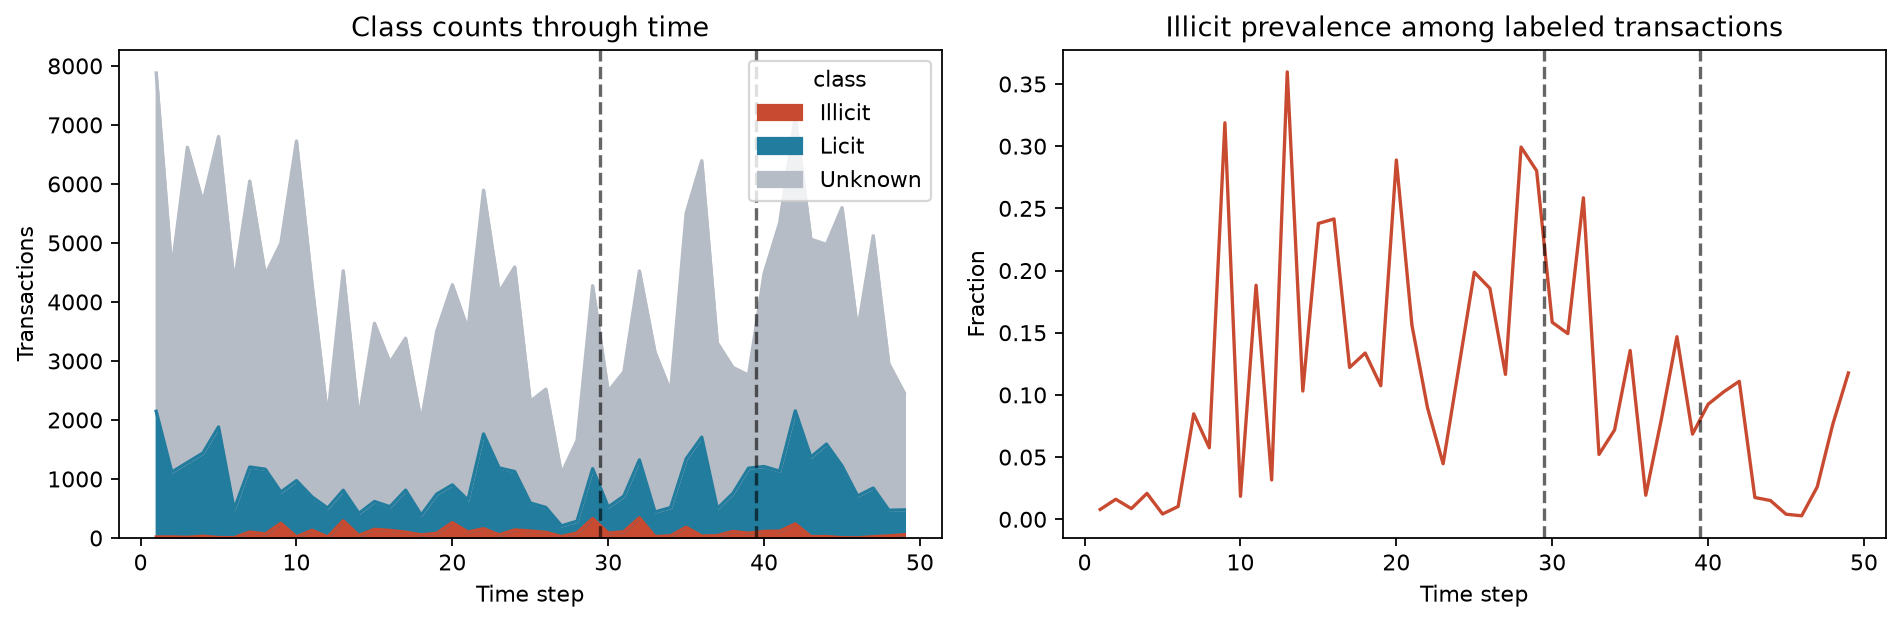

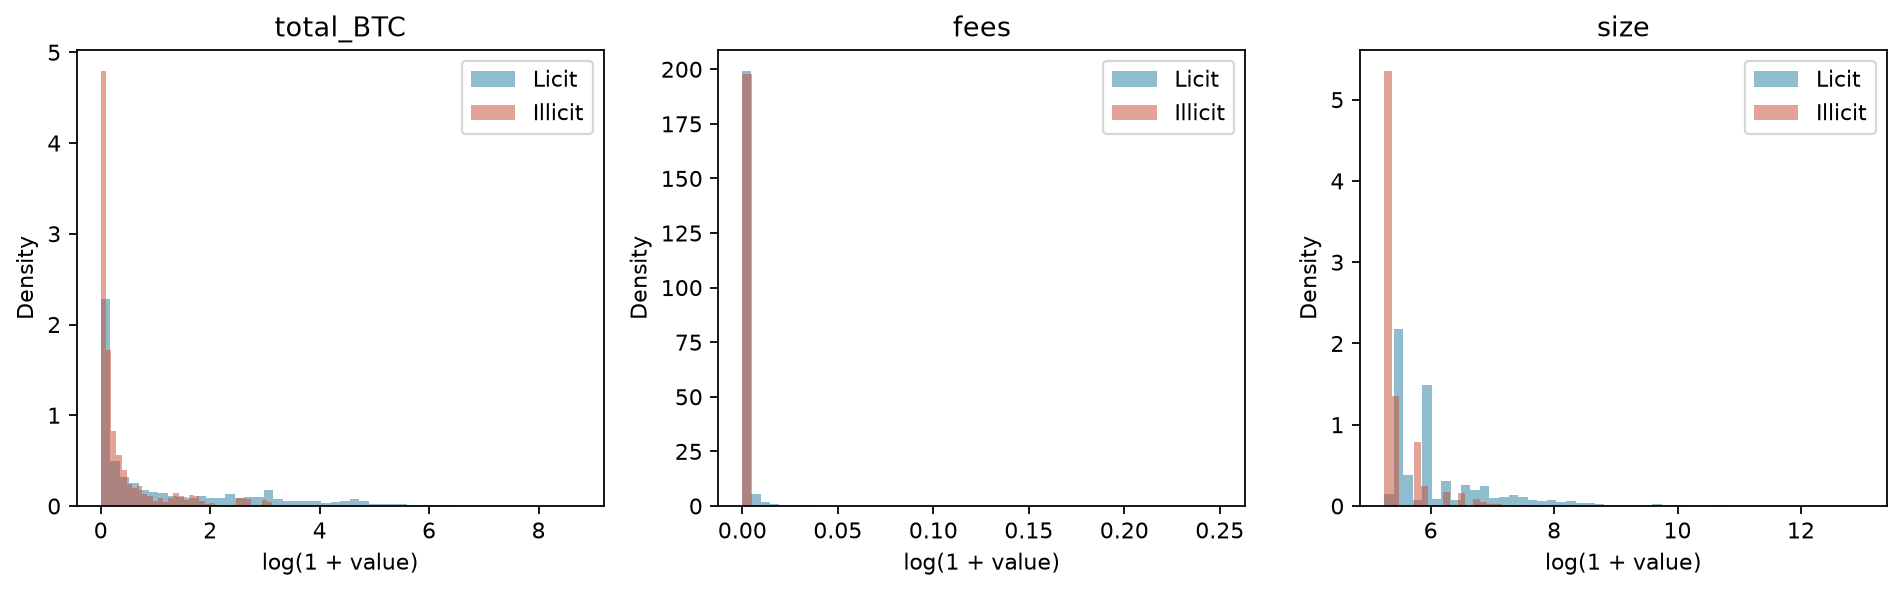

In [2]:
figure("class_and_time.png")
figure("transaction_distributions.png")

In [3]:
f = pd.read_parquet(ROOT / "data/processed/transactions.parquet")
known = f[f.y.notna()]
summary = known.groupby("split").y.agg(["size", "sum", "mean"])
summary.columns = ["labeled", "illicit", "illicit_prevalence"]
display(summary)

,labeled,illicit,illicit_prevalence
split,,,
test,11184,636.0,0.056867
train,26381,2871.0,0.108828
validation,8999,1038.0,0.115346


Pooled metrics can conceal changes in illicit prevalence and behavior. Compare validation with test before describing a model as stable. Histogram transforms are visualization choices, not extra model preprocessing. Unknown outcomes dominate the population and prevent population-wide performance claims.